# Capstone Step 5: Data Wrangling & Exploration
### Music Genre Classifier — GTZAN Audio Features

This notebook covers the required **data wrangling** work and the **optional data
exploration (EDA)** step for the capstone: cleaning the extracted-audio-feature
dataset, checking it for missing values / duplicates / outliers, and exploring
which features actually separate the ten music genres before any modeling is
attempted in Step 7.

**Dataset:** `data/data.csv` — audio features extracted (via `librosa`) from the
GTZAN Genre Collection: 1,000 thirty-second clips, 100 per genre, across
blues, classical, country, disco, hip-hop, jazz, metal, pop, reggae, and rock.
Each row is one track; columns are tempo/beat, spectral, chroma, timbral
(MFCC 1–20) features, plus the genre `label`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

## 1. Load the dataset

In [2]:
df = pd.read_csv("data/data.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head().to_string())

Shape: 1000 rows, 30 columns
         filename       tempo  beats  chroma_stft      rmse  spectral_centroid  spectral_bandwidth      rolloff  zero_crossing_rate       mfcc1       mfcc2      mfcc3      mfcc4      mfcc5      mfcc6      mfcc7      mfcc8      mfcc9     mfcc10     mfcc11     mfcc12     mfcc13    mfcc14    mfcc15    mfcc16     mfcc17     mfcc18     mfcc19     mfcc20  label
0  blues.00081.au  103.359375     50     0.380260  0.248262        2116.942959         1956.611056  4196.107960            0.127272  -26.929785  107.334008 -46.809993  40.932634 -21.463776  24.816275 -18.945571  15.253459 -15.050104  12.262823 -15.234050  14.336612 -13.821769  7.562789 -6.181372  0.330165  -6.829571   0.965922  -7.570825   2.918987  blues
1  blues.00022.au   95.703125     44     0.306451  0.113475        1156.070496         1497.668176  2170.053545            0.058613 -233.860772  136.170239   3.289490  48.931193   8.699106  13.954752   5.359449   0.381334 -13.490265  16.871769   5.145258 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   filename            1000 non-null   str    
 1   tempo               1000 non-null   float64
 2   beats               1000 non-null   int64  
 3   chroma_stft         1000 non-null   float64
 4   rmse                1000 non-null   float64
 5   spectral_centroid   1000 non-null   float64
 6   spectral_bandwidth  1000 non-null   float64
 7   rolloff             1000 non-null   float64
 8   zero_crossing_rate  1000 non-null   float64
 9   mfcc1               1000 non-null   float64
 10  mfcc2               1000 non-null   float64
 11  mfcc3               1000 non-null   float64
 12  mfcc4               1000 non-null   float64
 13  mfcc5               1000 non-null   float64
 14  mfcc6               1000 non-null   float64
 15  mfcc7               1000 non-null   float64
 16  mfcc8             

## 2. Cleaning steps performed

1. Inspect structure, dtypes, and value ranges.
2. Check for missing values.
3. Check for duplicate rows / duplicate source files.
4. Check genre-label consistency (casing, whitespace, unexpected categories).
5. Detect and treat outliers (IQR method).
6. Encode the genre label and scale numeric features for downstream modeling.
7. Build a stratified prototyping subset for fast experimentation.

Each step below shows the actual code and its output — nothing here is
hypothetical.

### 2.1 Missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values found in any column.")
else:
    print(missing)

No missing values found in any column.


No missing values were present in this extract. (If a future re-extraction
introduces gaps — e.g. a librosa feature that fails on a corrupted clip — the
plan is: drop rows with a missing `label`, since the target can't be imputed,
and median-impute missing numeric features, since audio features are skewed
and median is robust to the outliers audio data commonly has.)

### 2.2 Duplicate records

In [5]:
full_dupes = df.duplicated().sum()
name_dupes = df.duplicated(subset=["filename"]).sum()
print(f"Fully duplicated rows: {full_dupes}")
print(f"Duplicate filenames:   {name_dupes}")

Fully duplicated rows: 0
Duplicate filenames:   0


No duplicate rows or duplicate source filenames were found.

### 2.3 Genre label consistency

In [6]:
print("Unique labels:", sorted(df['label'].unique()))
print()
print(df['label'].value_counts())

Unique labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


All ten labels are lowercase, consistently spelled, and **perfectly
balanced at 100 tracks each** — good news for training, since we won't need
class-weighting or resampling later.

### 2.4 Outlier detection (IQR method)

In [7]:
def iqr_outlier_counts(frame, cols):
    counts = {}
    for c in cols:
        q1, q3 = frame[c].quantile(0.25), frame[c].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        counts[c] = int(((frame[c] < lower) | (frame[c] > upper)).sum())
    return pd.Series(counts).sort_values(ascending=False)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = iqr_outlier_counts(df, numeric_cols)
print("Columns with the most IQR outliers:")
print(outlier_counts.head(10))

Columns with the most IQR outliers:
mfcc1                 27
mfcc20                23
beats                 21
mfcc19                15
tempo                 13
mfcc18                12
mfcc16                 9
mfcc17                 9
zero_crossing_rate     6
mfcc3                  5
dtype: int64


`mfcc1`, `mfcc20`, `beats`, and `tempo` carry the most IQR-flagged points.
For audio features this is expected and not automatically "bad data" — a
very fast or very slow track (e.g. some metal or classical pieces) can be a
legitimate genre trait rather than a measurement error. Rather than deleting
these rows and losing whole tracks (and unbalancing the genre counts), we
**winsorize** (clip) each flagged numeric column to its IQR fences. This caps
the influence of extreme values while keeping every track in the dataset.

In [8]:
df_clean = df.copy()
for c in numeric_cols:
    q1, q3 = df_clean[c].quantile(0.25), df_clean[c].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df_clean[c] = df_clean[c].clip(lower, upper)

print("Outlier counts after clipping (should all be 0):")
print(iqr_outlier_counts(df_clean, numeric_cols).head(5))

Outlier counts after clipping (should all be 0):
tempo                0
beats                0
chroma_stft          0
rmse                 0
spectral_centroid    0
dtype: int64


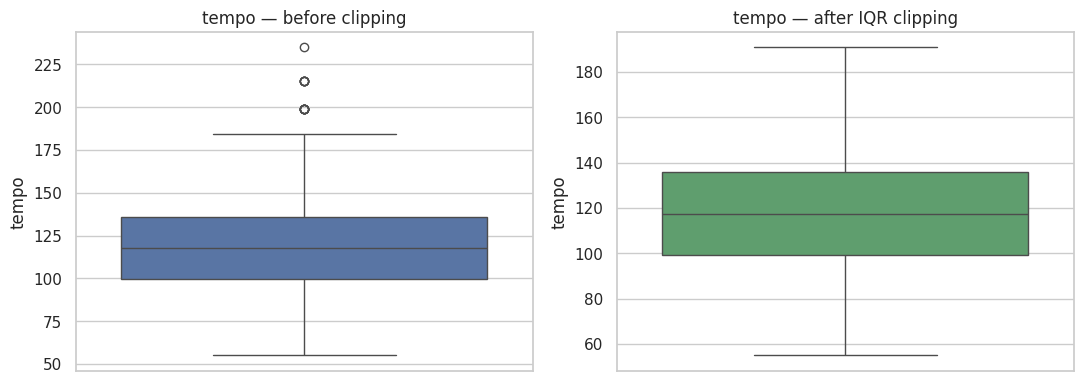

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df["tempo"], ax=axes[0], color="#4C72B0")
axes[0].set_title("tempo — before clipping")
sns.boxplot(y=df_clean["tempo"], ax=axes[1], color="#55A868")
axes[1].set_title("tempo — after IQR clipping")
plt.tight_layout()
plt.show()

### 2.5 Encoding and scaling

In [10]:
le = LabelEncoder()
df_clean["label_encoded"] = le.fit_transform(df_clean["label"])
print("Genre -> encoded label mapping:")
for genre, code_val in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {genre:10s} -> {code_val}")

Genre -> encoded label mapping:
  blues      -> 0
  classical  -> 1
  country    -> 2
  disco      -> 3
  hiphop     -> 4
  jazz       -> 5
  metal      -> 6
  pop        -> 7
  reggae     -> 8
  rock       -> 9


In [11]:
feature_cols = [c for c in numeric_cols if c not in ("label_encoded",)]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean[feature_cols])
df_scaled = pd.DataFrame(scaled_features, columns=feature_cols)
print("Scaled feature means (should be ~0):")
print(df_scaled.mean().round(3).head(6))
print()
print("Scaled feature stds (should be ~1):")
print(df_scaled.std().round(3).head(6))

Scaled feature means (should be ~0):
tempo                -0.0
beats                 0.0
chroma_stft           0.0
rmse                 -0.0
spectral_centroid     0.0
spectral_bandwidth    0.0
dtype: float64

Scaled feature stds (should be ~1):
tempo                 1.001
beats                 1.001
chroma_stft           1.001
rmse                  1.001
spectral_centroid     1.001
spectral_bandwidth    1.001
dtype: float64


### 2.6 Train/test split and a prototyping subset

In [12]:
X = df_clean[feature_cols]
y = df_clean["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print()
print("Class balance is preserved in the split:")
print((y_train.value_counts(normalize=True) * 100).round(1))

Train: 800 rows, Test: 200 rows

Class balance is preserved in the split:
label
jazz         10.0
country      10.0
rock         10.0
hiphop       10.0
pop          10.0
reggae       10.0
metal        10.0
blues        10.0
classical    10.0
disco        10.0
Name: proportion, dtype: float64


In [13]:
# A smaller stratified subset for fast iteration while prototyping models (Step 7),
# without needing the full dataset for every experiment.
prototype_df, _ = train_test_split(
    df_clean, train_size=0.25, stratify=df_clean["label"], random_state=42
)
print(f"Prototype subset: {prototype_df.shape[0]} rows "
      f"({prototype_df.shape[0] / df_clean.shape[0]:.0%} of full data)")
print(prototype_df['label'].value_counts())

Prototype subset: 250 rows (25% of full data)
label
hiphop       25
reggae       25
disco        25
jazz         25
metal        25
blues        25
rock         25
classical    25
pop          25
country      25
Name: count, dtype: int64


At only 1,000 rows and ~30 columns, the full dataset is small enough to train
on directly — the 25% stratified subset above exists purely to speed up early
model comparisons in Step 7, not because the full data is unwieldy.

## 3. Data Exploration (EDA)

With a clean dataset in hand, this section looks for the trends and
significant features the capstone brief asks for: which variables separate
the genres, and how correlated the independent variables are with each
other.

### 3.1 Genre distribution

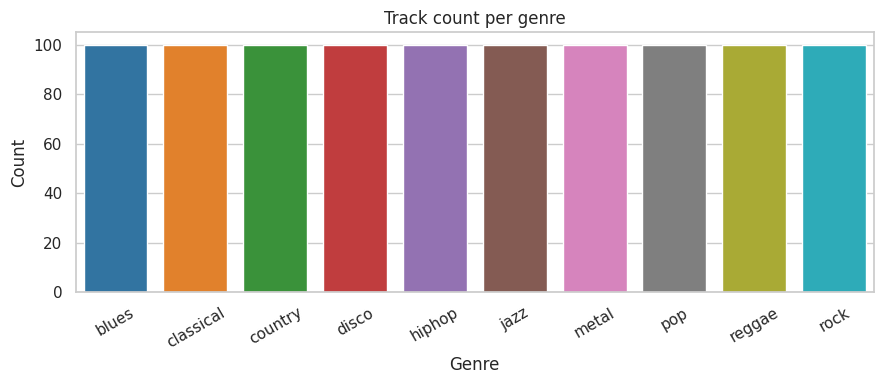

In [14]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df_clean, x="label", order=sorted(df_clean["label"].unique()),
              palette="tab10")
plt.title("Track count per genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 Feature distributions across genres

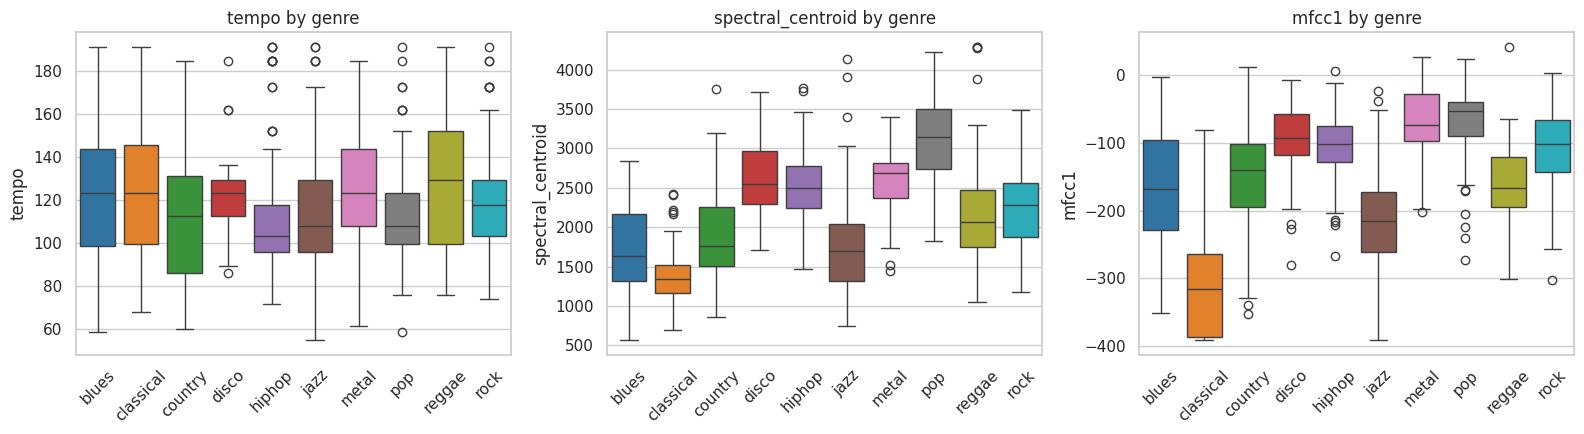

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["tempo", "spectral_centroid", "mfcc1"]):
    order = sorted(df_clean["label"].unique())
    sns.boxplot(data=df_clean, x="label", y=col, order=order, ax=ax, palette="tab10")
    ax.set_title(f"{col} by genre")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

`mfcc1` (overall timbral energy) shows the clearest genre-to-genre spread —
classical and jazz sit apart from metal and hip-hop. `spectral_centroid`
("brightness" of the sound) separates the harsher genres (metal, rock) from
the softer ones (classical). `tempo` overlaps heavily across genres, which
foreshadows the ANOVA result in section 3.4: tempo alone is a weak genre
predictor.

### 3.3 Correlation between independent variables

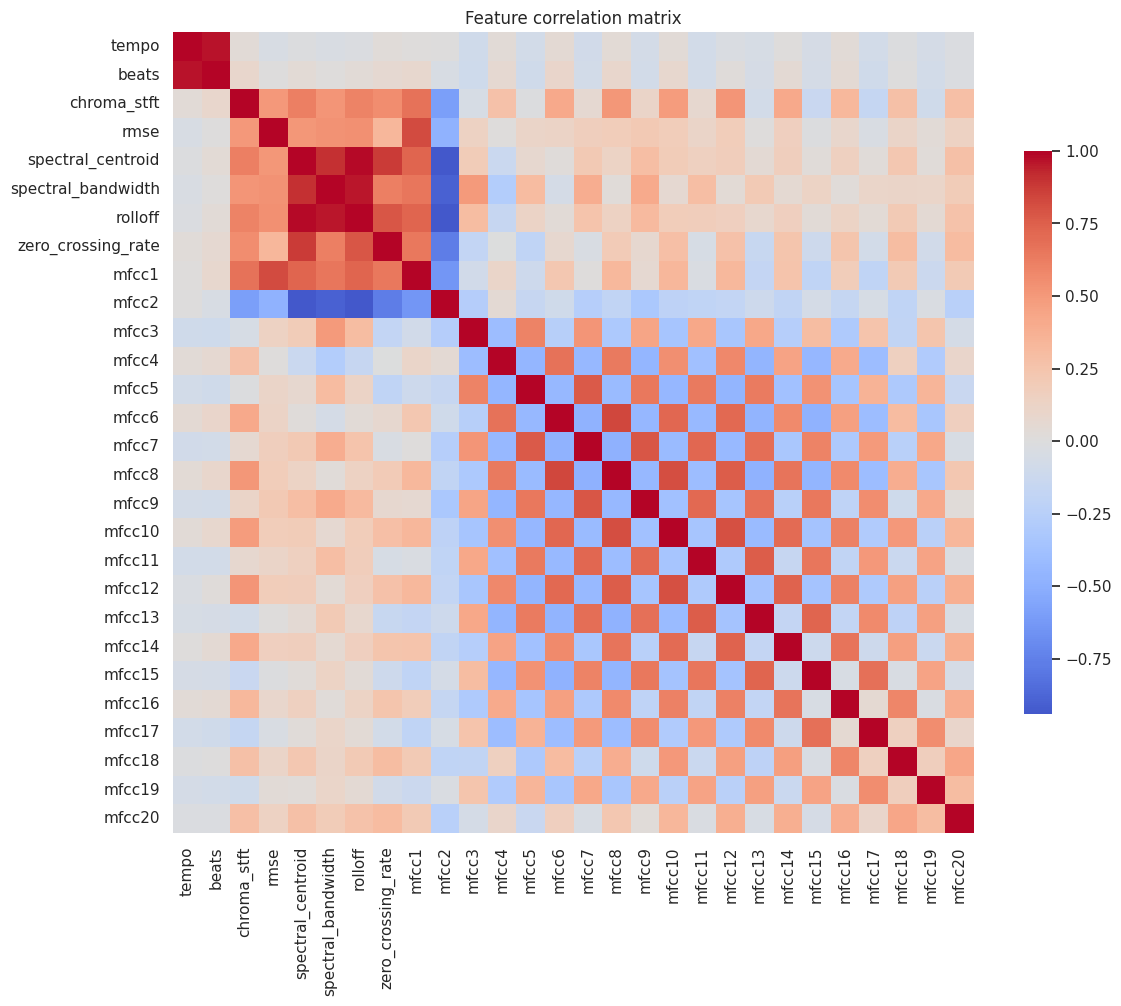

In [16]:
plt.figure(figsize=(12, 10))
corr = df_clean[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

In [17]:
corr_abs = corr.abs()
pairs = (corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
                 .stack()
                 .sort_values(ascending=False))
print("Most strongly correlated feature pairs:")
print(pairs.head(10).round(3))

Most strongly correlated feature pairs:
spectral_centroid   rolloff               0.980
tempo               beats                 0.965
spectral_bandwidth  rolloff               0.956
spectral_centroid   mfcc2                 0.941
rolloff             mfcc2                 0.935
spectral_centroid   spectral_bandwidth    0.905
spectral_bandwidth  mfcc2                 0.898
spectral_centroid   zero_crossing_rate    0.875
mfcc6               mfcc8                 0.838
rmse                mfcc1                 0.819
dtype: float64


`spectral_centroid` / `rolloff` (r ≈ 0.98) and `tempo` / `beats` (r ≈ 0.97)
are near-duplicates of each other, as expected — `beats` is essentially
tempo × track length, and `rolloff` and `spectral_centroid` both summarize
where energy sits in the frequency spectrum. `spectral_centroid` is also
highly correlated with `mfcc2` and `spectral_bandwidth`. This redundancy is
worth keeping in mind for Step 7: tree-based models will shrug it off, but a
linear model or PCA step would benefit from dropping one of each redundant
pair (e.g. keep `rolloff`, drop `spectral_centroid`).

### 3.4 Which features actually explain genre? (ANOVA F-test)

In [18]:
F_scores, p_values = f_classif(df_clean[feature_cols], df_clean["label"])
significance = (pd.DataFrame({"feature": feature_cols, "F_score": F_scores, "p_value": p_values})
                 .sort_values("F_score", ascending=False)
                 .reset_index(drop=True))
print("Top 10 most genre-discriminative features (ANOVA F-test):")
print(significance.head(10).to_string(index=False))
print()
print("Least discriminative features:")
print(significance.tail(5).to_string(index=False))

Top 10 most genre-discriminative features (ANOVA F-test):
           feature    F_score       p_value
       chroma_stft 178.666415 1.730804e-200
             mfcc1 128.815117 6.101456e-160
spectral_bandwidth 116.619108 9.616437e-149
           rolloff 110.896033 2.781747e-143
 spectral_centroid  97.725783 3.641367e-130
             mfcc4  83.857557 1.941000e-115
             mfcc2  83.639617 3.369831e-115
              rmse  74.950143 2.000787e-105
             mfcc8  68.111546  2.055790e-97
             mfcc6  66.105814  5.242129e-95

Least discriminative features:
feature   F_score      p_value
 mfcc16 17.937695 8.513880e-28
 mfcc20 16.202052 5.428065e-25
 mfcc18 11.473829 3.061114e-17
  tempo  5.429350 2.707606e-07
  beats  4.598930 5.692355e-06


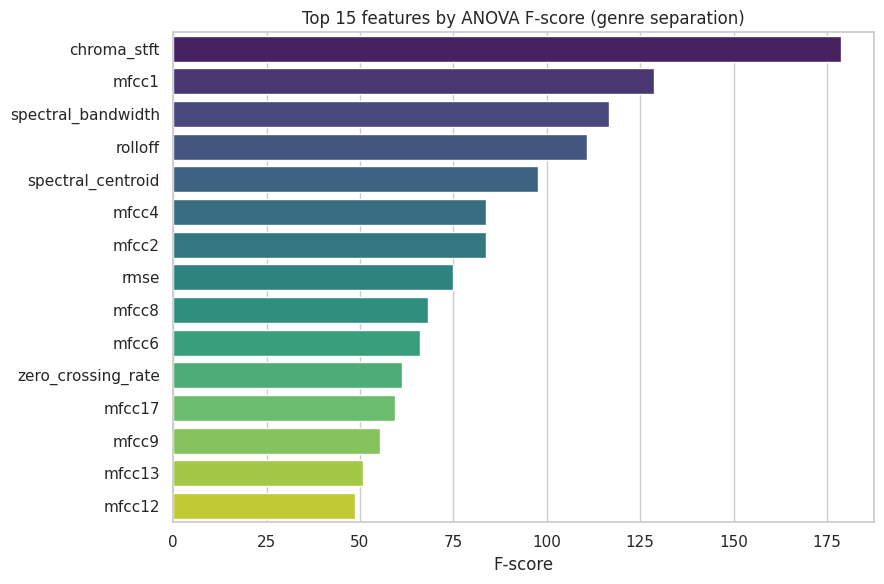

In [19]:
plt.figure(figsize=(9, 6))
top15 = significance.head(15)
sns.barplot(data=top15, y="feature", x="F_score", palette="viridis")
plt.title("Top 15 features by ANOVA F-score (genre separation)")
plt.xlabel("F-score")
plt.ylabel("")
plt.tight_layout()
plt.show()

`chroma_stft`, `mfcc1`, `spectral_bandwidth`, `rolloff`, and `spectral_centroid`
are the strongest single-feature genre discriminators (largest F-scores, all
with p < 0.001). `tempo` and `beats` — despite being the most "intuitive"
musical descriptors — are the **weakest** discriminators in the whole
feature set, confirming what the boxplots in 3.2 suggested: genres in this
dataset overlap heavily in tempo, so a model leaning on tempo alone would
underperform. This is useful signal heading into Step 7: timbral (MFCC) and
spectral features are doing most of the real classification work.

## 4. Summary

**Cleaning:**
- No missing values, no duplicate rows or filenames, all 10 genre labels
  consistently spelled and perfectly balanced (100 tracks each) — no
  resampling needed.
- IQR-based outlier detection flagged a modest number of points, concentrated
  in `mfcc1`, `mfcc20`, `beats`, and `tempo`; these were winsorized (clipped
  to the IQR fences) rather than dropped, preserving every track.
- Genre label was label-encoded; numeric features were standard-scaled for
  downstream modeling.
- An 80/20 stratified train/test split, and a 25% stratified subset for fast
  Step 7 prototyping, both preserve genre balance.

**Exploration:**
- `chroma_stft`, `mfcc1`, `spectral_bandwidth`, `rolloff`, and
  `spectral_centroid` are the most genre-discriminative individual features
  (ANOVA F-test); `tempo` and `beats` are the least.
- `spectral_centroid`/`rolloff` and `tempo`/`beats` are highly correlated
  (r > 0.96), so keeping both adds little beyond redundancy for linear
  models.
- These findings point Step 7 toward models that can exploit the MFCC/
  spectral feature space (e.g. tree ensembles, SVM with RBF kernel) rather
  than relying on tempo/rhythm features alone.